In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load Nigeria data
df = pd.read_csv('../data/nigeria.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [3]:
# Add country name
df['Country'] = 'Nigeria'
df = df.replace(-999, np.nan)

In [4]:
# Convert dates
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


In [5]:
# Remove duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dropped {duplicates} duplicates")

In [6]:
# Handle missing values
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
for col in weather_cols:
    if col in df.columns:
        df[col] = df[col].ffill()

In [7]:
# Export cleaned data
df.to_csv('../data/nigeria_clean.csv', index=False)
print("Cleaned data saved to: data/nigeria_clean.csv")

Cleaned data saved to: data/nigeria_clean.csv


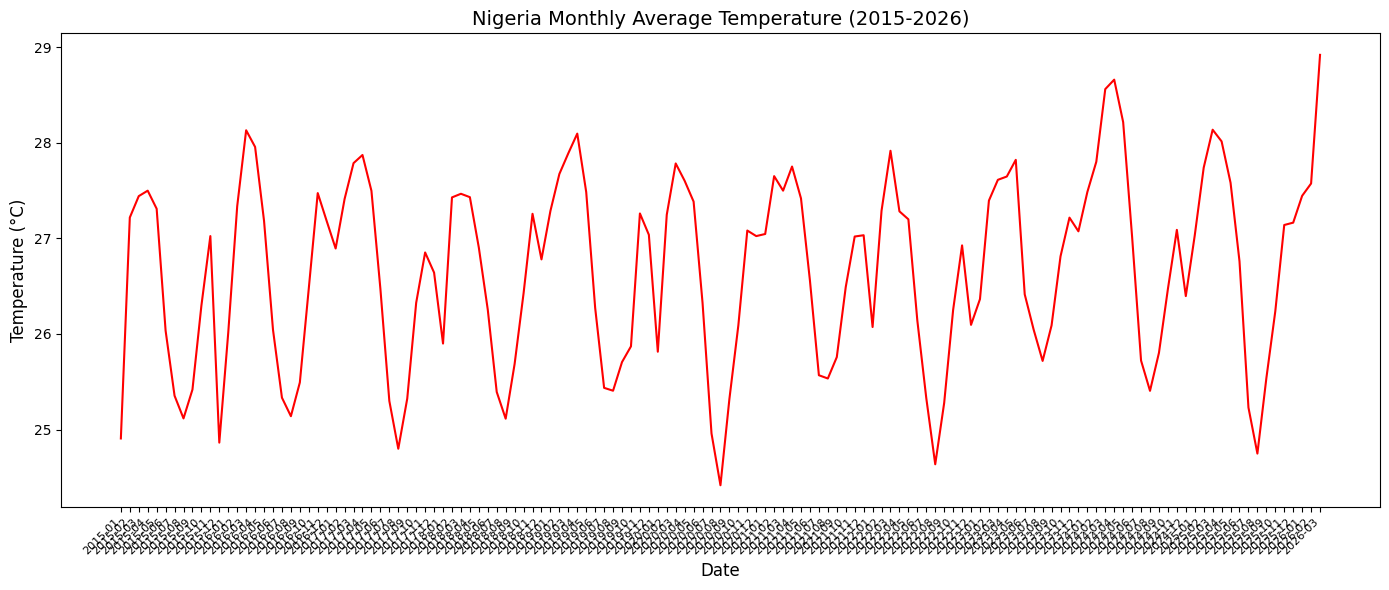

In [8]:
# Temperature plot
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index.astype(str), monthly_temp.values, linewidth=1.5, color='red')
plt.title('Nigeria Monthly Average Temperature (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

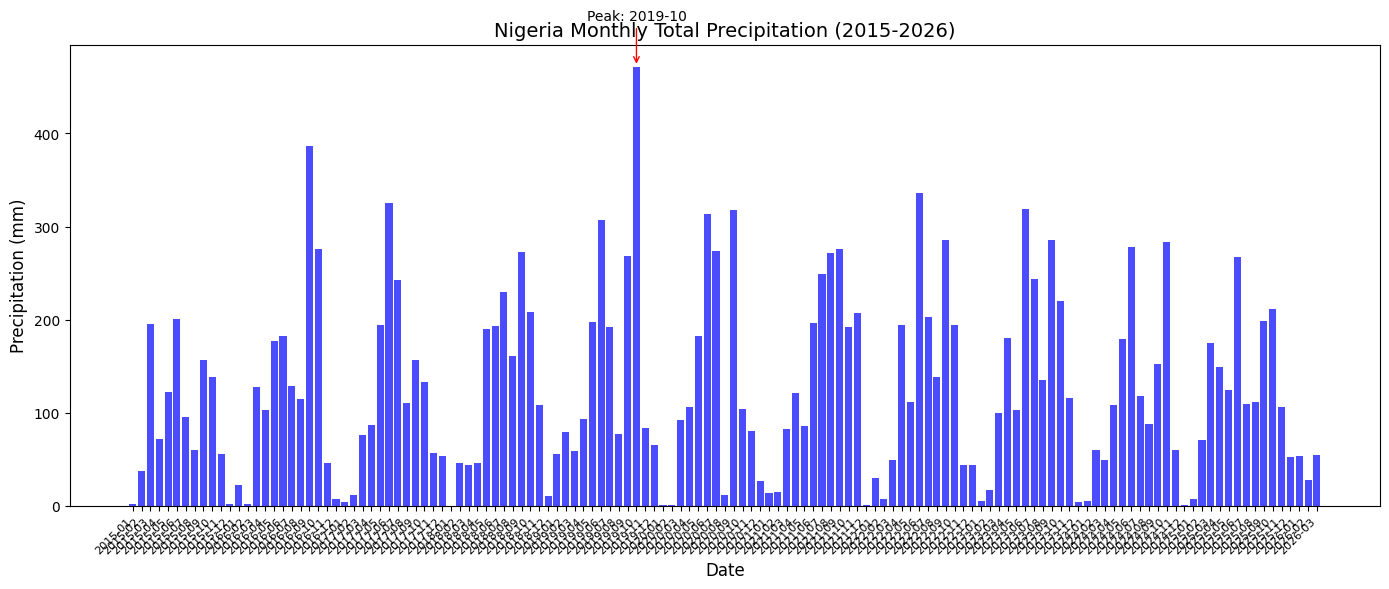

In [10]:
# Monthly total precipitation bar chart
monthly_precip = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()

plt.figure(figsize=(14, 6))
plt.bar(monthly_precip.index.astype(str), monthly_precip.values, color='blue', alpha=0.7)

peak_month = monthly_precip.idxmax()
peak_value = monthly_precip.max()
plt.annotate(f'Peak: {peak_month}', xy=(str(peak_month), peak_value), 
             xytext=(str(peak_month), peak_value + 50),
             ha='center', fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Nigeria Monthly Total Precipitation (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

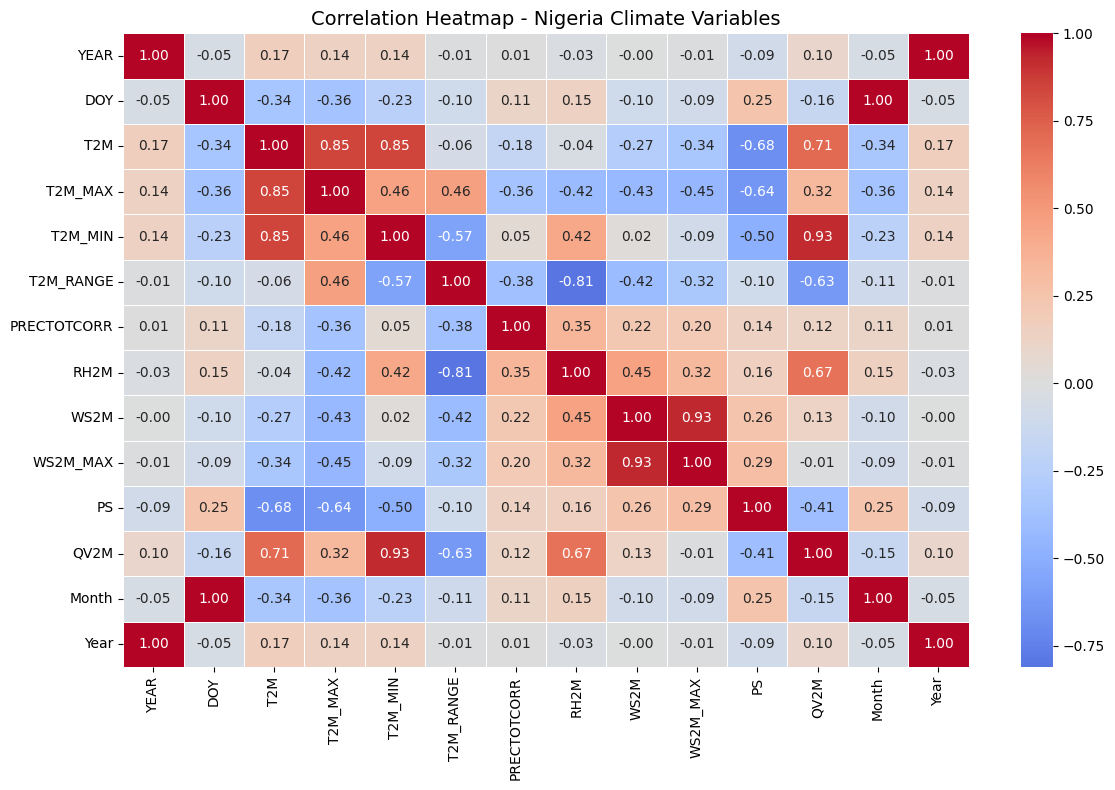


Top 3 strongest correlations:
Year      YEAR    1.000000
Month     DOY     0.996557
WS2M_MAX  WS2M    0.930498
dtype: float64


In [11]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Nigeria Climate Variables', fontsize=14)
plt.tight_layout()
plt.show()
# Top 3 strongest correlations
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corrs = upper.unstack().dropna().sort_values(ascending=False).head(3)
print("\nTop 3 strongest correlations:")
print(top_corrs)


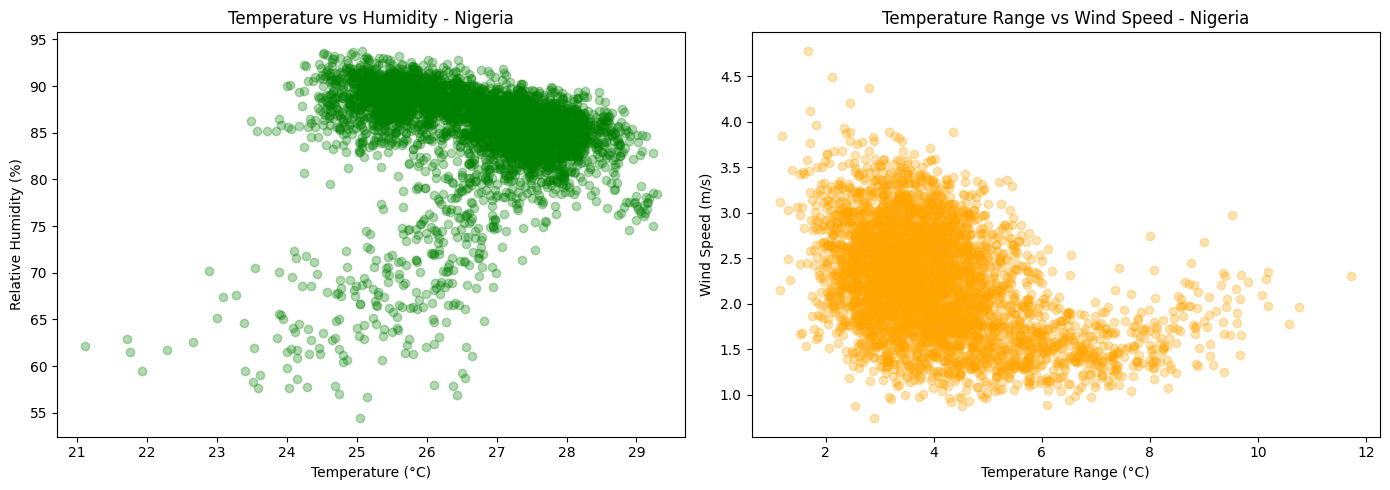

In [12]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, color='green')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Temperature vs Humidity - Nigeria')

axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='orange')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Temperature Range vs Wind Speed - Nigeria')

plt.tight_layout()
plt.show()


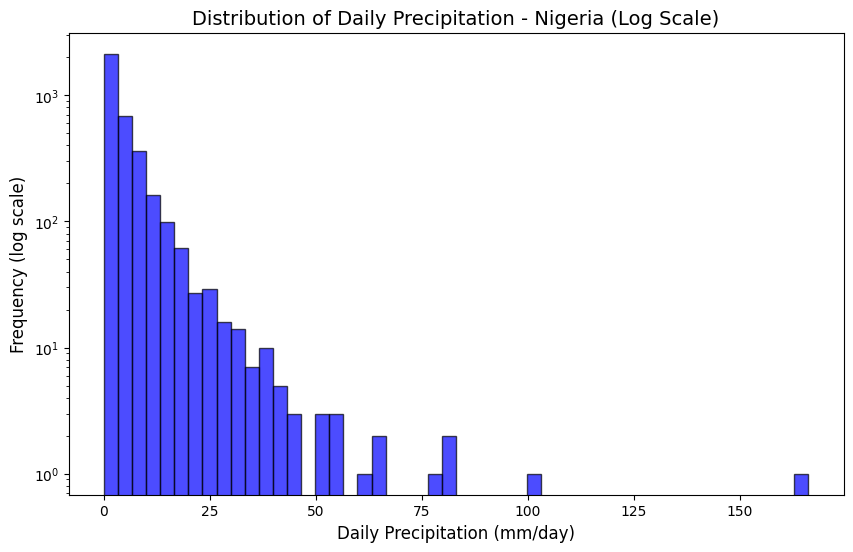


Most days have low precipitation (0-5 mm), with few extreme rainfall events
Nigeria EDA complete!


In [13]:
# Precipitation histogram (log scale)
plt.figure(figsize=(10, 6))
precip_data = df['PRECTOTCORR'].dropna()
precip_data = precip_data[precip_data > 0]

plt.hist(precip_data, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.yscale('log')
plt.xlabel('Daily Precipitation (mm/day)', fontsize=12)
plt.ylabel('Frequency (log scale)', fontsize=12)
plt.title('Distribution of Daily Precipitation - Nigeria (Log Scale)', fontsize=14)
plt.show()

print("\nMost days have low precipitation (0-5 mm), with few extreme rainfall events")
print("Nigeria EDA complete!")